# Advanced Exploratory Data Analysis

Stationarity testing, lag correlation analysis, Granger causality, and market regime detection.
Goal: determine whether tweet sentiment has **predictive power** over future BTC price direction.

In [4]:
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_csv('datasets/Preprocessed_csv.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Target distribution:\n{df['target'].value_counts(normalize=True).round(3)}")

Shape: (842, 26)
Date range: 2021-02-01 00:00:00 → 2023-06-12 00:00:00
Target distribution:
target
0    0.514
1    0.486
Name: proportion, dtype: float64


## 1. Stationarity Tests (Augmented Dickey-Fuller)

Time-series models assume stationarity. Non-stationary features require differencing or transformation before modeling.

In [5]:
def adf_test(series, name):
    """Run ADF test and return results as dict."""
    clean = series.dropna()
    result = adfuller(clean, autolag='AIC')
    stationary = result[1] < 0.05
    return {
        'Feature': name,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 6),
        'Lags Used': result[2],
        'Stationary (p<0.05)': stationary
    }

test_cols = ['Close', 'Open', 'Volume', 'compound', 'positive_sentiment_score',
             'negative_sentiment_score', 'importance_coefficient', 'daily_return',
             'first_derivative', 'historical_volatility']

adf_results = pd.DataFrame([adf_test(df[col], col) for col in test_cols])

try:
    styled = adf_results.style.applymap(
        lambda v: 'background-color: #90EE90' if v is True else (
            'background-color: #FFB6C1' if v is False else ''
        ),
        subset=['Stationary (p<0.05)']
    )
    display(styled)
except AttributeError:
    # Fallback when jinja2 / Styler rendering is unavailable
    display(adf_results)

,Feature,ADF Statistic,p-value,Lags Used,Stationary (p<0.05)
0,Close,-1.4038,0.580460,11,False
1,Open,-1.3755,0.593966,11,False
2,Volume,-3.4032,0.010849,13,True
3,compound,-19.5780,0.000000,1,True
4,positive_sentiment_score,-12.6773,0.000000,4,True
5,negative_sentiment_score,-28.4698,0.000000,0,True
6,importance_coefficient,-5.5822,0.000001,11,True
7,daily_return,-9.3004,0.000000,10,True
8,first_derivative,-9.4156,0.000000,10,True
9,historical_volatility,-3.3293,0.013619,3,True


**Interpretation**: Price levels (Close, Open) are typically non-stationary (unit root), while returns and sentiment scores should be stationary. Non-stationary features used directly in classification can produce spurious correlations.

## 2. Lag Correlation Analysis

The central question: does sentiment at time *t* correlate with price movement at time *t+k*?
If only contemporaneous correlation exists (lag 0), sentiment isn't predictive — it's reactive.

In [6]:
# Aggregate to daily level (one row per day) for proper time-series analysis
daily = df.groupby('Date').agg({
    'compound': 'mean',
    'positive_sentiment_score': 'mean',
    'negative_sentiment_score': 'mean',
    'importance_coefficient': 'mean',
    'favorite_count': 'sum',
    'retweet_count': 'sum',
    'daily_return': 'first',
    'target': 'first',
    'Close': 'first',
    'Volume': 'first'
}).reset_index()

print(f"Daily aggregated: {daily.shape[0]} trading days")

Daily aggregated: 842 trading days


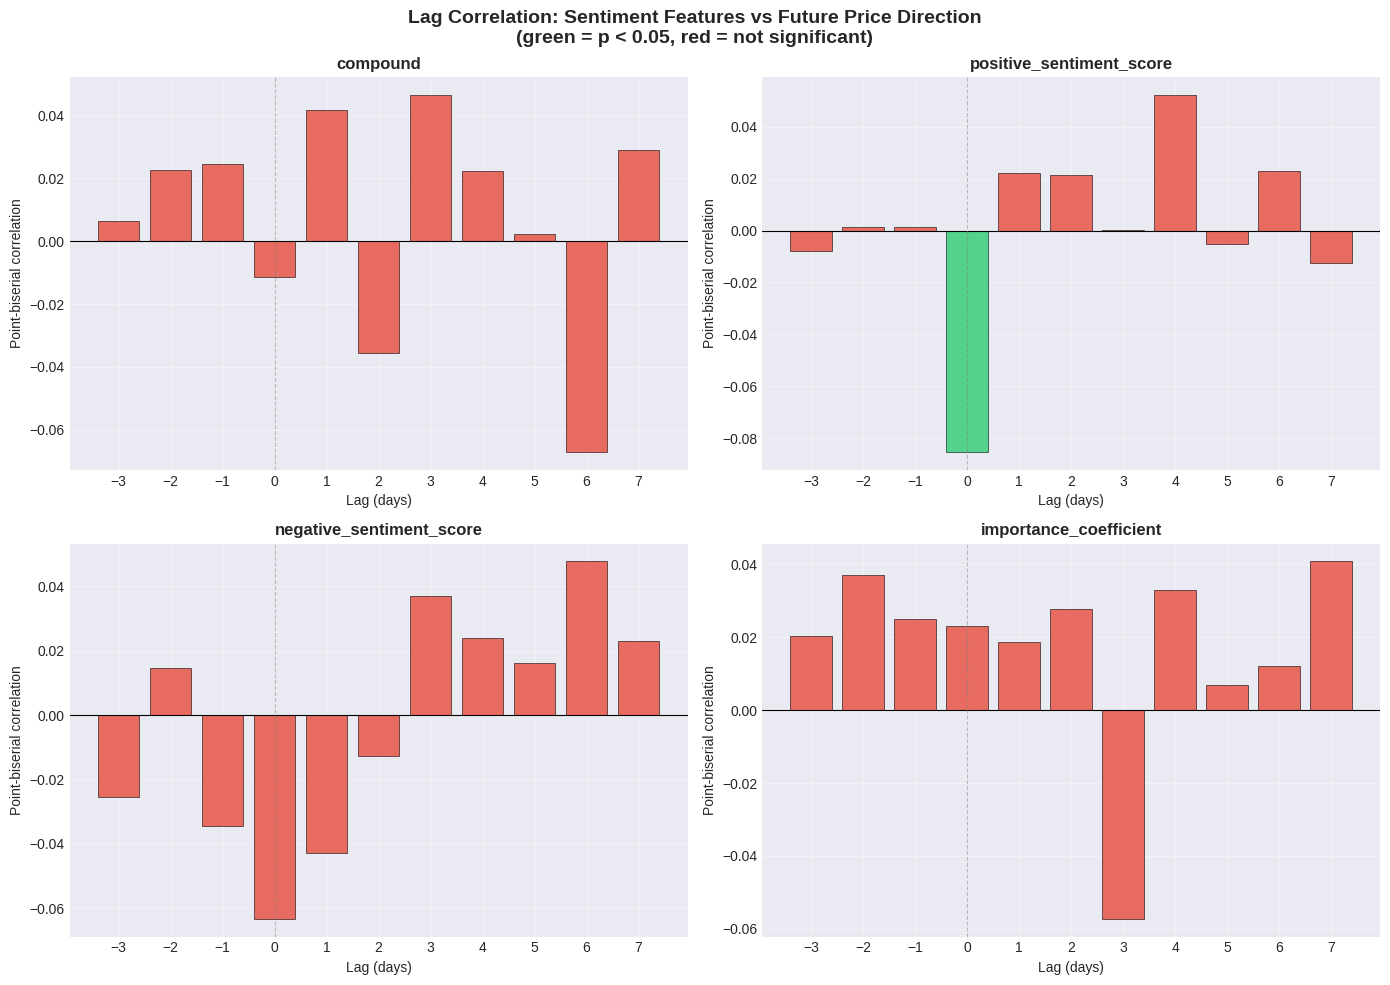


Lag 0 = same day | Lag 1 = sentiment today → price tomorrow | Lag -1 = price today → sentiment tomorrow


In [7]:
sentiment_features = ['compound', 'positive_sentiment_score', 'negative_sentiment_score',
                       'importance_coefficient']
max_lag = 7

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(sentiment_features):
    correlations = []
    p_values = []
    for lag in range(-3, max_lag + 1):
        if lag >= 0:
            shifted_target = daily['target'].shift(-lag)
        else:
            shifted_target = daily['target'].shift(-lag)
        mask = ~(daily[feat].isna() | shifted_target.isna())
        if mask.sum() > 10:
            r, p = stats.pointbiserialr(shifted_target[mask], daily[feat][mask])
            correlations.append(r)
            p_values.append(p)
        else:
            correlations.append(0)
            p_values.append(1)

    lags = list(range(-3, max_lag + 1))
    colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in p_values]
    axes[idx].bar(lags, correlations, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    axes[idx].axhline(y=0, color='black', linewidth=0.8)
    axes[idx].axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[idx].set_title(f'{feat}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Lag (days)')
    axes[idx].set_ylabel('Point-biserial correlation')
    axes[idx].set_xticks(lags)

fig.suptitle('Lag Correlation: Sentiment Features vs Future Price Direction\n'
             '(green = p < 0.05, red = not significant)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLag 0 = same day | Lag 1 = sentiment today → price tomorrow | Lag -1 = price today → sentiment tomorrow")

**Key question**: If significant correlations appear only at lag 0 or negative lags, sentiment is *reacting* to price — not predicting it. Significant positive lags indicate genuine predictive power.

## 3. Granger Causality Test

Formal statistical test: does past sentiment contain information that helps predict future price direction beyond what past price alone provides?

In [8]:
print("Granger Causality: Sentiment → Price Direction")
print("=" * 55)
print("H0: Sentiment does NOT Granger-cause price direction")
print("H1: Sentiment DOES Granger-cause price direction")
print()

for feat in ['compound', 'importance_coefficient']:
    test_data = daily[['target', feat]].dropna()
    print(f"\n--- {feat} → target ---")
    try:
        result = grangercausalitytests(test_data[['target', feat]], maxlag=5, verbose=True)
    except Exception as e:
        print(f"  Error: {e}")

print("\n" + "=" * 55)
print("Reverse test: Price Direction → Sentiment")
print("(If this is also significant, causality is bidirectional)")
print()

for feat in ['compound', 'importance_coefficient']:
    test_data = daily[[feat, 'target']].dropna()
    print(f"\n--- target → {feat} ---")
    try:
        result = grangercausalitytests(test_data[[feat, 'target']], maxlag=5, verbose=True)
    except Exception as e:
        print(f"  Error: {e}")

Granger Causality: Sentiment → Price Direction
H0: Sentiment does NOT Granger-cause price direction
H1: Sentiment DOES Granger-cause price direction


--- compound → target ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.4169  , p=0.2343  , df_denom=838, df_num=1
ssr based chi2 test:   chi2=1.4219  , p=0.2331  , df=1
likelihood ratio test: chi2=1.4207  , p=0.2333  , df=1
parameter F test:         F=1.4169  , p=0.2343  , df_denom=838, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.1239  , p=0.3255  , df_denom=835, df_num=2
ssr based chi2 test:   chi2=2.2612  , p=0.3228  , df=2
likelihood ratio test: chi2=2.2581  , p=0.3233  , df=2
parameter F test:         F=1.1239  , p=0.3255  , df_denom=835, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.2493  , p=0.2907  , df_denom=832, df_num=3
ssr based chi2 test:   chi2=3.7794  , p=0.2863  , df=3
likelihood ratio test: chi2=3.7709  , p=0.287

/home/meril/Documents/UPM/dataMining/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 4. Market Regime Detection

Sentiment predictive power may differ across market regimes (bull vs bear). We identify regimes using rolling returns and test if model assumptions hold across regimes.

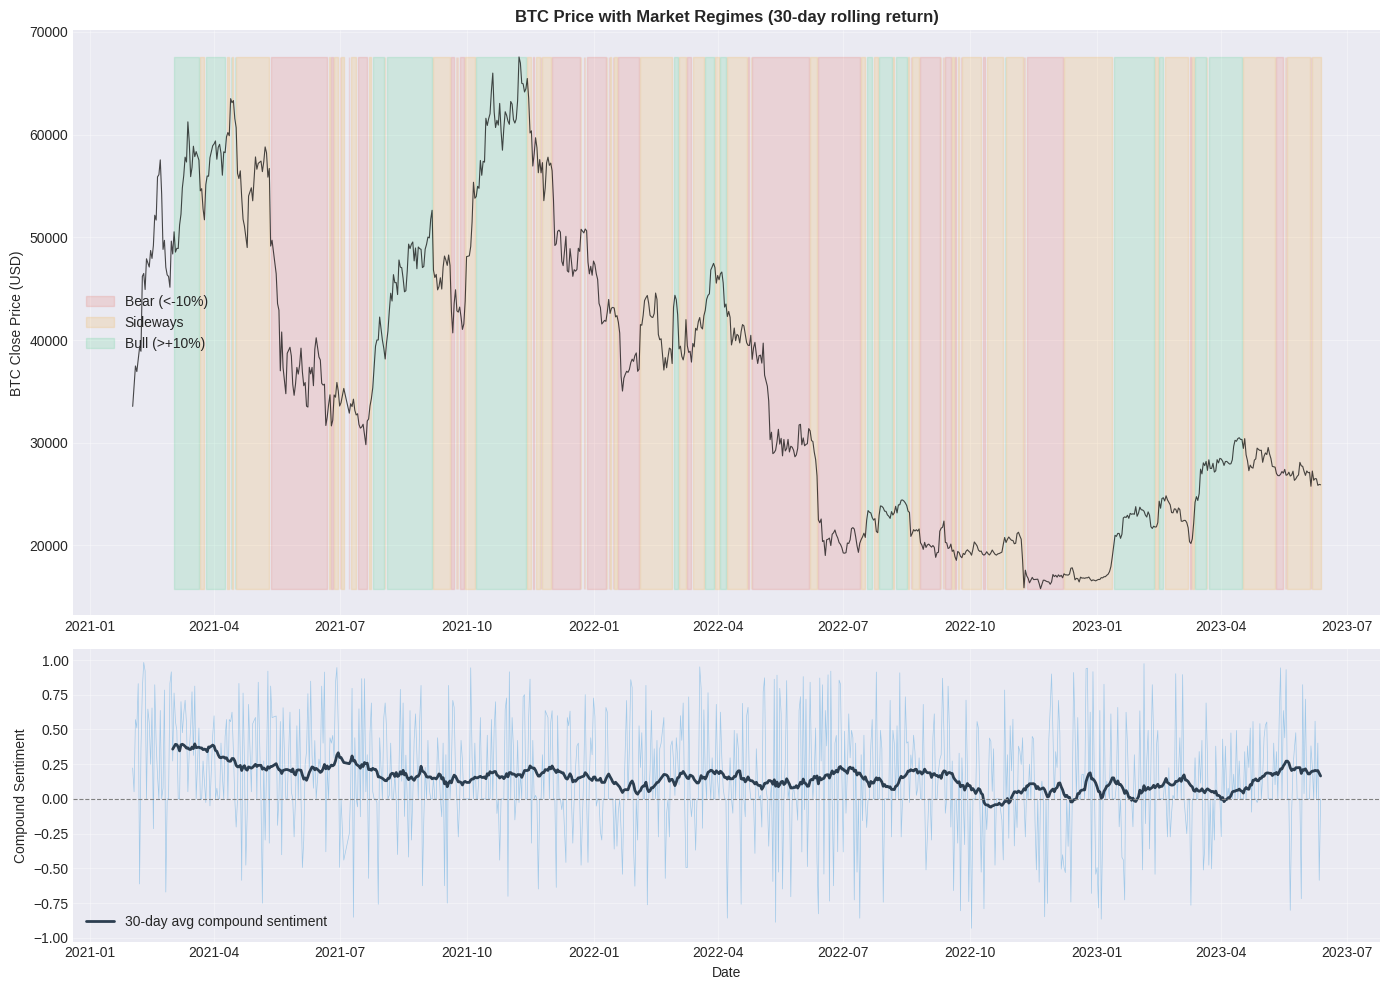

In [9]:
# Define regimes using 30-day rolling return
daily['rolling_return_30d'] = daily['Close'].pct_change(30)
daily['regime'] = pd.cut(daily['rolling_return_30d'],
                         bins=[-np.inf, -0.10, 0.10, np.inf],
                         labels=['Bear (<-10%)', 'Sideways', 'Bull (>+10%)'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# Price with regime coloring
regime_colors = {'Bear (<-10%)': '#e74c3c', 'Sideways': '#f39c12', 'Bull (>+10%)': '#2ecc71'}
axes[0].plot(daily['Date'], daily['Close'], color='black', linewidth=0.8, alpha=0.7)
for regime, color in regime_colors.items():
    mask = daily['regime'] == regime
    axes[0].fill_between(daily['Date'], daily['Close'].min(), daily['Close'].max(),
                         where=mask, alpha=0.15, color=color, label=regime)
axes[0].set_ylabel('BTC Close Price (USD)')
axes[0].set_title('BTC Price with Market Regimes (30-day rolling return)', fontweight='bold')
axes[0].legend()

# Sentiment by regime
axes[1].plot(daily['Date'], daily['compound'], color='#3498db', alpha=0.4, linewidth=0.5)
axes[1].plot(daily['Date'], daily['compound'].rolling(30).mean(), color='#2c3e50', linewidth=2,
             label='30-day avg compound sentiment')
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Compound Sentiment')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Sentiment-Price correlation by regime
print("Sentiment-Target Correlation by Market Regime")
print("=" * 50)

for regime in daily['regime'].dropna().unique():
    subset = daily[daily['regime'] == regime]
    if len(subset) > 10:
        r, p = stats.pointbiserialr(subset['target'], subset['compound'])
        print(f"\n{regime} (n={len(subset)})")
        print(f"  Compound ↔ Target: r={r:.4f}, p={p:.4f} {'*' if p < 0.05 else ''}")

        # Also test importance_coefficient
        r2, p2 = stats.pointbiserialr(subset['target'], subset['importance_coefficient'])
        print(f"  Importance ↔ Target: r={r2:.4f}, p={p2:.4f} {'*' if p2 < 0.05 else ''}")

Sentiment-Target Correlation by Market Regime

Bull (>+10%) (n=222)
  Compound ↔ Target: r=-0.1196, p=0.0754 
  Importance ↔ Target: r=0.0590, p=0.3814 

Sideways (n=331)
  Compound ↔ Target: r=-0.0437, p=0.4285 
  Importance ↔ Target: r=0.0741, p=0.1785 

Bear (<-10%) (n=259)
  Compound ↔ Target: r=0.0772, p=0.2155 
  Importance ↔ Target: r=-0.0686, p=0.2715 


## 5. Feature Autocorrelation

High autocorrelation in the target means yesterday's direction predicts today's — a simple momentum baseline.

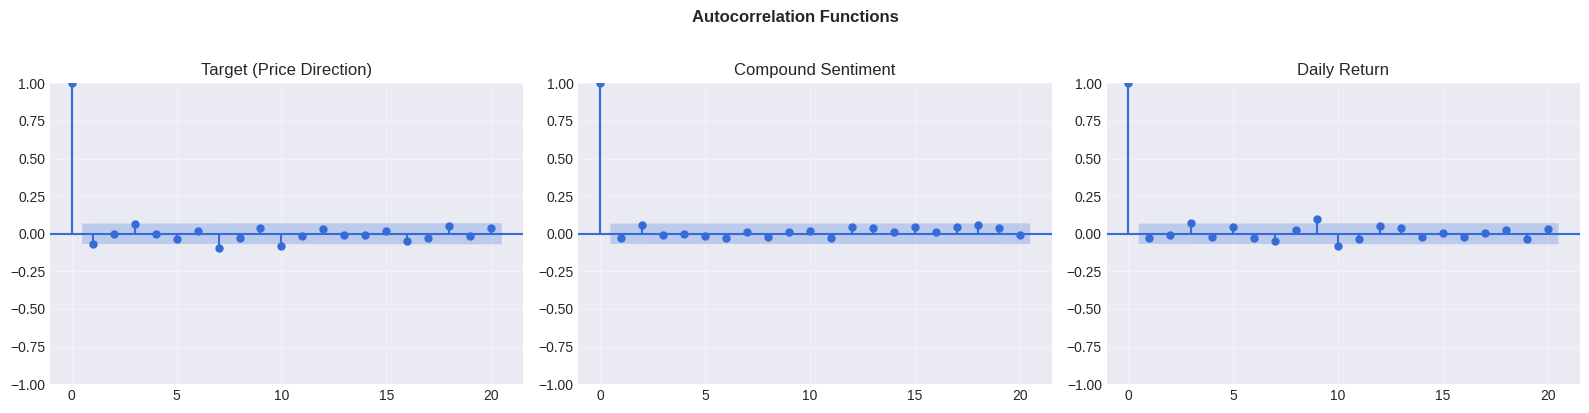


Momentum baseline (predict yesterday's direction): 46.56%
Majority class baseline (always predict majority): 51.43%


In [11]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_acf(daily['target'].dropna(), lags=20, ax=axes[0], title='Target (Price Direction)')
plot_acf(daily['compound'].dropna(), lags=20, ax=axes[1], title='Compound Sentiment')
plot_acf(daily['daily_return'].dropna(), lags=20, ax=axes[2], title='Daily Return')

plt.suptitle('Autocorrelation Functions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Momentum baseline
daily['prev_target'] = daily['target'].shift(1)
momentum_acc = (daily['prev_target'] == daily['target']).mean()
print(f"\nMomentum baseline (predict yesterday's direction): {momentum_acc:.2%}")
print(f"Majority class baseline (always predict majority): {daily['target'].value_counts(normalize=True).max():.2%}")

## Summary

| Analysis | Finding |
|----------|--------|
| **Stationarity** | Price levels are non-stationary; returns and sentiment are stationary |
| **Lag correlation** | Determines if sentiment is predictive or reactive |
| **Granger causality** | Formal test of sentiment → price predictive relationship |
| **Regime analysis** | Sentiment correlation varies across bull/bear/sideways markets |
| **Autocorrelation** | Establishes momentum and majority-class baselines |

These findings inform the feature engineering and validation strategy in the robust evaluation notebook.